## Introduction

Ever wondered how computers can write stories or answer your questions in a surprisingly human-like way? The magic often lies in something called a Language Model! But not all language models need to be giant beasts. In this tutorial, we're going to embark on an exciting journey to build our very own **Small Language Model (SLM)** from scratch! Think of it as teaching a mini-brain to understand and generate text, keeping it lean and efficient with around 50-60 million parameters.

Our ultimate goal is to empower this little linguistic wizard to generate creative and coherent text based on the input we provide. By the end, you'll have a deeper understanding of the building blocks that make large language models tick, but on a scale that's much easier to grasp and experiment with.

### What You'll Learn

*   **Data Preparation:** How to load and tokenize a dataset suitable for training a language model.
*   **Model Architecture:** Deconstructing the core components of a Transformer-based language model, including attention mechanisms and feed-forward networks.
*   **Training Setup:** Configuring the training loop, optimizers, and learning rate schedulers for efficient model training.
*   **Model Training:** The process of training a language model from raw data to a functional text generator.
*   **Text Generation:** How to use the trained SLM to generate new, creative text based on a given prompt.
*   **Performance Evaluation:** Basic methods for monitoring and evaluating the training progress and model performance.

## Welcome to Indaba Nigeria 2026! 🇳🇬

Before we dive into the exciting world of Small Language Models, let's take a moment to appreciate where we are. You're here at **Indaba Nigeria 2026**, part of the larger Deep Learning Indaba movement.

But what does "Indaba" even mean? In many Southern African languages, an **Indaba** is a traditional gathering or meeting to discuss important matters. It's a place for coming together, sharing knowledge, and collective problem-solving.

And that's exactly what we're doing here! This hands-on session is designed to embody the spirit of Indaba: to learn, explore, and build together. We're thrilled to have you join us on this journey to demystify and create a Small Language Model. Get ready to collaborate, ask questions, and maybe even teach your SLM a new trick or two!

### Exercise 1.1: Explore the TinyStories Dataset

Let's get familiar with the TinyStories dataset. We'll start by checking its structure, available splits, and then peek at a few examples.

**Task:**
1.  Inspect the `ds` object to understand its structure (e.g., keys, splits).
2.  Print the keys present in the dataset.
3.  Display an example entry from the training split to see the story content.

## Step 1: Import and Explore the Dataset: TinyStories 📚

To train our Small Language Model, we need a dataset that's both manageable and interesting. Enter **TinyStories**! This fascinating dataset, available on HuggingFace, consists of short stories designed specifically for language models. What makes it special?

*   **Simplified Vocabulary:** TinyStories is synthetic, meaning it was generated by powerful models like GPT-3.5 and GPT-4. However, it's constrained to use words typically understood by 3 to 4-year-olds. This makes it perfect for training a smaller model, as it reduces the complexity of the language space our SLM needs to master.
*   **Focus on Narrative:** Each entry is a coherent, simple story, providing excellent material for our SLM to learn basic narrative structures and text generation.

This dataset allows us to build a functional SLM without requiring immense computational resources, making our hands-on journey much more accessible.

Let's get started by loading the dataset!

In [ ]:
!pip install datasets

In [ ]:
pip install -U datasets


In [ ]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

(…)-00000-of-00004-2d5a1467fff1081b.parquet:   0%|          | 0.00/249M [00:00<?, ?B/s]

(…)-00001-of-00004-5852b56a2bd28fd9.parquet:   0%|          | 0.00/248M [00:00<?, ?B/s]

(…)-00002-of-00004-a26307300439e943.parquet:   0%|          | 0.00/246M [00:00<?, ?B/s]

(…)-00003-of-00004-d243063613e5a057.parquet:   0%|          | 0.00/248M [00:00<?, ?B/s]

(…)-00000-of-00001-869c898b519ad725.parquet:   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [ ]:
# 1. Inspect the dataset structure and splits
print("Dataset Structure:")
print(ds)

# 2. Print the keys available in the dataset (e.g., 'train', 'validation')
print("\nDataset Keys/Splits:")
print(ds.keys())

# 3. Display an example entry from the training split
print("\nExample from Training Split:")
print(ds['train'][0]['text'])

## Step 2: Tokenize the Dataset: Speaking the Language of Models 📝

For our Small Language Model to understand and generate text, we first need to convert human-readable sentences into a format it can process: numerical tokens. This process is called **tokenization**.

Think of it like teaching a child to read; they first learn individual letters, then words, and then sentences. Our SLM learns from these numerical representations of words or sub-word units.

In this step, we will:

1.  **Tokenize the dataset into tokenIDs:** We'll break down the stories into a sequence of numbers, where each number corresponds to a specific word or sub-word in our vocabulary. We'll be using `tiktoken`, a fast tokenizer developed by OpenAI, which is the same encoding used by models like GPT-2.
2.  **Create binary files (`train.bin` and `validation.bin`):** Instead of keeping all token IDs in RAM, which can be memory-intensive for large datasets, we'll store them efficiently on disk using `numpy.memmap`. This allows us to work with datasets larger than available memory and makes training more efficient.
3.  **Ensure efficient data handling:** By storing tokenIDs on disk and loading them as needed, we optimize memory usage and improve the performance of our training pipeline.

Let's prepare our dataset for the model!

### Exercise 4.2: Calculate Model Parameters

Understanding the number of parameters in your model is crucial for estimating its complexity and memory footprint. For our GPT model, the total parameters come from several components:

1.  **Token Embeddings (`wte`):** `vocab_size * n_embd`
2.  **Positional Embeddings (`wpe`):** `block_size * n_embd`
3.  **Layer Normalizations:** Each LayerNorm has `2 * n_embd` parameters (weight and bias).
4.  **Multi-Head Attention (`CausalSelfAttention`):**
    *   `c_attn` (query, key, value projections): `3 * n_embd * n_embd` (input to output `3 * n_embd`)
    *   `c_proj` (output projection): `n_embd * n_embd`
5.  **MLP (`Feed-Forward Network`):**
    *   `c_fc` (expansion layer): `n_embd * (4 * n_embd)`
    *   `c_proj` (projection layer): `(4 * n_embd) * n_embd`

Remember that the `Transformer` blocks (`h`) are stacked `n_layer` times.

**Task:**
Calculate the total number of parameters for the GPT model using the `config` object defined previously. Consider the number of layers, embedding dimensions, and other relevant parameters. Print the total parameter count.

In [ ]:
n_layer = config.n_layer
n_head = config.n_head
n_embd = config.n_embd
vocab_size = config.vocab_size
block_size = config.block_size
bias = config.bias

def get_num_params(config):
    # Token Embeddings + Positional Embeddings
    total_params = vocab_size * n_embd + block_size * n_embd

    # For each Transformer Block
    # Each block contains two LayerNorms, one CausalSelfAttention, and one MLP
    for _ in range(n_layer):
        # LayerNorms (2 per block)
        total_params += 2 * (n_embd + (n_embd if bias else 0)) # weight and optional bias

        # CausalSelfAttention
        # c_attn: 3 * n_embd * n_embd (input to output 3*n_embd)
        total_params += (3 * n_embd * n_embd) + (3 * n_embd if bias else 0)
        # c_proj: n_embd * n_embd
        total_params += (n_embd * n_embd) + (n_embd if bias else 0)

        # MLP
        # c_fc: n_embd * (4 * n_embd)
        total_params += (n_embd * 4 * n_embd) + (4 * n_embd if bias else 0)
        # c_proj: (4 * n_embd) * n_embd
        total_params += (4 * n_embd * n_embd) + (n_embd if bias else 0)

    # Final LayerNorm
    total_params += n_embd + (n_embd if bias else 0)

    # Language Model Head (lm_head) - Note: weight tied with wte, so only bias if present
    # The weight is shared, so we only count if it's not tied, or if there's a separate bias
    # In this specific GPT implementation, lm_head shares weight with wte, no separate bias for lm_head

    # The weight tying means that lm_head.weight == transformer.wte.weight
    # So, we don't count vocab_size * n_embd again for lm_head.
    # if bias for lm_head, we would add vocab_size parameters.
    return total_params

calculated_params = get_num_params(config)
print(f"Calculated total parameters: {calculated_params:,}")

# Or, more simply, use PyTorch's built-in way to count parameters:
total_params_torch = sum(p.numel() for p in model.parameters())
print(f"Total parameters (PyTorch count): {total_params_torch:,}")

# Let's compare with the target range of 50-60 million
print(f"Target parameter range: 50-60 million")

### Step 4.1: Configure the SLM: Setting Model Parameters

Before we instantiate our GPT model, we need to define its configuration. The `GPTConfig` class holds all the essential hyperparameters that dictate the size and capabilities of our Small Language Model. Understanding these parameters is key to customizing and scaling your model.

Let's break down each parameter:

*   `vocab_size`: This is the total number of unique tokens your model can understand. It's derived from the tokenizer you use. For `tiktoken` with `gpt2` encoding, this is typically 50257.
*   `block_size`: Also known as the context window or sequence length. This defines the maximum number of tokens the model can look at simultaneously when making a prediction. A larger `block_size` allows the model to capture longer-range dependencies but requires more memory and computation.
*   `n_layer`: The number of Transformer blocks (layers) stacked in the model. More layers generally lead to a more powerful model but increase complexity and training time.
*   `n_head`: The number of attention heads in the Multi-Head Self-Attention mechanism within each Transformer block. More heads allow the model to attend to different parts of the input sequence simultaneously, capturing diverse relationships.
*   `n_embd`: The dimensionality of the token embeddings and the internal representation size throughout the Transformer blocks. This is a crucial factor determining the model's capacity.
*   `dropout`: A regularization technique used to prevent overfitting. It randomly sets a fraction of neurons to zero during training, forcing the network to learn more robust features.
*   `bias`: A boolean indicating whether to use bias terms in linear layers throughout the model. Generally, setting this to `True` is standard practice.

These parameters collectively determine the model's complexity and its ability to learn from the data. We'll set these values to create our SLM, aiming for around 50-60 million parameters as outlined in the introduction.

### Exercise 2.1: Tokenize the TinyStories Dataset

Now, let's execute the tokenization process. The following cell will:

1.  Install `tiktoken`.
2.  Initialize the `gpt2` tokenizer.
3.  Define a `process` function to encode each story.
4.  Map this function over the dataset splits.
5.  Save the tokenized IDs into `train.bin` and `validation.bin` files using `numpy.memmap` for efficient storage.

**Task:**
Run the cell below and observe the output, particularly the progress bars for tokenizing and writing the binary files. Confirm that `train.bin` and `validation.bin` are created in your Colab environment (you can check the file explorer on the left sidebar).

In [ ]:
!pip install tiktoken
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

enc = tiktoken.get_encoding("gpt2")

# Some functions from https://github.com/karpathy/nanoGPT/blob/master/data/openwebtext/prepare.py

def process(example):
    ids = enc.encode_ordinary(example['text']) # encode_ordinary ignores any special tokens
    out = {'ids': ids, 'len': len(ids)}
    return out

if not os.path.exists("train.bin"):
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8,
        )
    # concatenate all the ids in each dataset into one large file we can use for training
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16 # (can do since enc.max_token_value == 50256 is < 2**16)
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            # Batch together samples for faster write
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            # Write into mmap
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()

tokenizing the splits (num_proc=8):   0%|          | 0/2119719 [00:00<?, ? examples/s]

tokenizing the splits (num_proc=8):   0%|          | 0/21990 [00:00<?, ? examples/s]

writing train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

writing validation.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

## Step 3: Create Input-Output Batches for the Dataset 🧩

With our stories tokenized into numerical IDs, the next crucial step is to prepare them for training. Language models learn by predicting the *next* token in a sequence. This means for every input sequence, there's a corresponding target sequence that is simply the input shifted by one token.

In this step, we'll implement a function to generate these input-output pairs (or `(X, Y)` batches) from our `train.bin` and `validation.bin` files. This process involves:

1.  **Loading Data Efficiently:** Using `numpy.memmap` to read token IDs from our binary files without loading the entire dataset into RAM.
2.  **Random Batch Selection:** Selecting random contiguous chunks (`block_size`) of token IDs from the dataset.
3.  **Creating Input (`X`) and Target (`Y`) Pairs:** For each chunk, `X` will be the sequence of `block_size` tokens, and `Y` will be the same sequence shifted by one position, representing the next token the model should predict.
4.  **Batching:** Stacking multiple `(X, Y)` pairs together to form a batch of `batch_size` samples, which allows for parallel processing on the GPU and more stable gradient updates.

Understanding how these batches are constructed is fundamental to comprehending the language model training process. Let's look at the `get_batch` function and then see it in action!

In [ ]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
#block size = context window
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


## Step 4: Define the SLM Model Architecture 🧠

Now for the exciting part: building our Small Language Model! We'll be constructing a simplified version of a **Generative Pre-trained Transformer (GPT)**. The Transformer architecture is the backbone of most modern large language models, renowned for its efficiency in handling sequential data like text.

Our GPT model will consist of several key components:

1.  **Token and Positional Embeddings (`wte` and `wpe`):** Before processing, each token (word or sub-word) is converted into a numerical vector (embedding). We also add positional embeddings to tell the model the order of words, as Transformers process words simultaneously rather than sequentially.
2.  **Transformer Blocks (`h`):** The core of the model, these blocks are stacked layers that process the input. Each block contains:
    *   **Layer Normalization:** Helps stabilize training and improves performance.
    *   **Multi-Head Causal Self-Attention:** This is where the magic happens! It allows the model to weigh the importance of different words in the input sequence when processing each word. 'Causal' means it only attends to previous words, preventing information leakage from future tokens (which is crucial for generation).
    *   **Feed-Forward Network (MLP):** A simple neural network that processes the output of the attention layer independently for each token, allowing the model to learn more complex patterns.
3.  **Final Layer Normalization (`ln_f`):** Another layer normalization before the final output.
4.  **Language Model Head (`lm_head`):** This is a linear layer that projects the final embeddings back into the vocabulary space, allowing the model to predict the probability distribution of the next token.

We'll also implement **weight tying** between the token embeddings (`wte`) and the language model head (`lm_head`). This means they share the same weight matrix, which can reduce the number of parameters and improve model efficiency, especially in smaller models.

Understanding these building blocks is fundamental to grasping how Transformer-based models process and generate human-like text. Let's look at the code that brings this architecture to life!

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx



In [ ]:
config = GPTConfig(
    vocab_size=50257,     # use the tokenizer's vocab size
    block_size=128,       # or whatever context size you're training with
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

## Step 5: Define the Loss Function and Evaluation Metrics

For our Small Language Model to learn effectively, it needs a way to measure how "wrong" its predictions are. This is where the **loss function** comes in. In the context of language modeling, we are typically trying to predict the next token in a sequence. Our loss function quantifies the difference between the model's predicted next token probabilities and the actual next token.

Here, we use **Cross-Entropy Loss**, a common choice for classification problems like predicting the next token from a vocabulary. The goal during training is to minimize this loss.

We also need a way to evaluate our model's performance beyond just the training loss. The `estimate_loss` function will help us:

1.  **Periodically evaluate performance:** By calculating the average loss over a small number of batches on both the training and validation sets.
2.  **Monitor for overfitting:** Comparing training loss to validation loss helps us understand if the model is learning generalizable patterns or simply memorizing the training data.
3.  **Determine when to save the best model:** We'll save the model weights that achieve the lowest validation loss.

Let's look at the `estimate_loss` function, which will give us a snapshot of our model's performance during training.

In [ ]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

## Step 6: Define SLM Training Configuration Part 1: Hyperparameters 🛠️

Training a language model involves carefully selecting various hyperparameters that control the learning process. These parameters are crucial for optimizing performance, managing computational resources, and ensuring stable training. In this section, we'll define the core training configurations for our Small Language Model.

Let's break down each parameter:

*   `learning_rate`: This determines the step size at which the model's weights are updated during training. A carefully chosen learning rate is critical for efficient convergence without overshooting the optimal solution.
*   `max_iters`: The total number of training iterations (batches processed). This dictates how long the model will train.
*   `warmup_steps`: The number of initial steps during which the learning rate gradually increases from a very small value to the initial `learning_rate`. This helps to stabilize training at the beginning.
*   `min_lr`: The minimum learning rate to which the scheduler will decay. This prevents the learning rate from dropping too low and potentially stalling training.
*   `eval_iters`: How frequently the model's performance is evaluated on both training and validation sets. This helps monitor progress and detect overfitting.
*   `batch_size`: The number of training examples processed in one forward/backward pass. Larger batches can provide more stable gradient estimates but require more memory.
*   `block_size`: Also known as context window or sequence length, this is the maximum number of tokens the model processes at once. It affects the model's ability to capture long-range dependencies.
*   `gradient_accumulation_steps`: This technique allows for simulating a larger `batch_size` than what fits in GPU memory. Gradients are accumulated over multiple mini-batches before a single optimization step is performed.
*   `device`: Specifies whether to use a GPU (`cuda`) or CPU for training. GPUs significantly speed up computations.
*   `dtype`: The data type for mixed-precision training (e.g., `bfloat16`, `float16`). Mixed precision uses lower precision formats to speed up training and reduce memory usage while maintaining numerical stability.
*   `ctx`: A context manager for `torch.amp.autocast`, which enables automatic mixed precision training based on the `dtype` and `device_type`.

These configurations will set the stage for our training loop, ensuring efficient and effective learning for our SLM.

In [ ]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 1e-4 #more stable training, earlier 1e-4
max_iters = 20000 #increase from 25000
warmup_steps = 1000 #smoother initial train, earlier 100
min_lr = 5e-4 #lower rate, earlier 5e-4
eval_iters = 500 # increased from 100
batch_size = 32 # changed from 16, better gradient estimate
block_size = 128 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

## Step 7: Define SLM Training Configuration Part 2: Optimizer, Schedulers, and Mixed Precision ⚙️

Beyond just defining the model and its basic hyperparameters, optimizing the training process requires a few more sophisticated components. In this section, we'll configure the **optimizer**, **learning rate schedulers**, and set up **mixed-precision training**.

*   **Optimizer (`torch.optim.AdamW`):** The optimizer is the engine that drives the learning process. It adjusts the model's weights and biases based on the calculated gradients to minimize the loss function. `AdamW` is a popular choice for Transformers due to its adaptive learning rate capabilities and built-in weight decay for regularization.

*   **Learning Rate Schedulers (`LinearLR`, `CosineAnnealingLR`, `SequentialLR`):** A fixed learning rate throughout training isn't always optimal. Learning rate schedulers dynamically adjust the learning rate during different phases of training, which can lead to faster convergence and better performance.
    *   **Warmup (`LinearLR`):** We'll use a linear warmup phase where the learning rate gradually increases from a very small value to the initial `learning_rate`. This helps stabilize training at the beginning, especially with large batch sizes or when using a new optimizer.
    *   **Decay (`CosineAnnealingLR`):** After the warmup, the learning rate will decay following a cosine curve. This smooth decay strategy helps the model fine-tune its weights and avoid oscillations as it approaches the optimum.
    *   **Sequential Scheduler (`SequentialLR`):** This combines our warmup and decay schedulers, allowing a seamless transition between the two phases.

*   **Mixed-Precision Training (`torch.cuda.amp.GradScaler`):** This advanced technique uses both 16-bit and 32-bit floating-point types during training. It provides significant benefits:
    *   **Faster Training:** 16-bit operations are often faster on modern GPUs.
    *   **Reduced Memory Usage:** Lower precision tensors require less memory, allowing for larger models or batch sizes.
    *   **`GradScaler`:** For `float16` mixed precision, `GradScaler` is essential. It helps prevent numerical underflow of small gradients by scaling them up during the backward pass and then scaling them back down before the optimizer step.

These components work together to ensure an efficient and stable training process for our Small Language Model.

In [ ]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

/tmp/ipython-input-2132813893.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


## Step 8: Pre-train the SLM 🚀

With our dataset tokenized, our model architecture defined, and all training configurations set, we are finally ready to pre-train our Small Language Model! This is the core phase where the model learns to predict the next token in a sequence, gradually improving its understanding of language patterns.

The training loop will iterate for a specified number of `max_iters`, performing the following key operations:

1.  **Batch Generation:** For each iteration, a batch of input (`X`) and target (`Y`) token sequences is generated using our `get_batch` function.
2.  **Forward Pass:** The model processes the input `X` to produce `logits` (raw predictions for the next token).
3.  **Loss Calculation:** The `logits` are compared against the true `targets` (`Y`) using the cross-entropy loss function. This quantifies how far off the model's predictions are.
4.  **Gradient Accumulation (if enabled):** If `gradient_accumulation_steps` is greater than 1, the gradients are accumulated over several mini-batches before a single optimization step is taken. This effectively simulates a larger batch size without requiring more GPU memory for each individual step.
5.  **Backward Pass & Optimization:** The calculated loss is used to compute gradients, which are then used by the `AdamW` optimizer to update the model's weights and biases. `GradScaler` is used for mixed-precision training to prevent underflow.
6.  **Learning Rate Scheduling:** The learning rate is adjusted according to the defined `SequentialLR` scheduler (warmup then cosine decay).
7.  **Evaluation:** Periodically (every `eval_iters`), the `estimate_loss` function is called to evaluate the model's performance on both the training and validation sets. This helps us monitor progress and detect overfitting.
8.  **Model Checkpointing:** The model's parameters are saved whenever a new best validation loss is achieved, ensuring we keep the best performing version of our SLM.

During this process, you'll observe the training and validation losses decreasing, indicating that the model is learning. Let the training begin!

In [ ]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/20000 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 500: train loss 9.4434, val loss 9.4478
The current learning rate: 0.00007


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 1000: train loss 8.4843, val loss 8.4880
The current learning rate: 0.00010
Epoch 1500: train loss 7.5319, val loss 7.5295
The current learning rate: 0.00010
Epoch 2000: train loss 6.6829, val loss 6.6796
The current learning rate: 0.00010
Epoch 2500: train loss 5.9868, val loss 5.9874
The current learning rate: 0.00011
Epoch 3000: train loss 5.4754, val loss 5.4753
The current learning rate: 0.00011
Epoch 3500: train loss 5.0568, val loss 5.0569
The current learning rate: 0.00012
Epoch 4000: train loss 4.7278, val loss 4.7268
The current learning rate: 0.00012
Epoch 4500: train loss 4.4928, val loss 4.4798
The current learning rate: 0.00013
Epoch 5000: train loss 4.2813, val loss 4.2910
The current learning rate: 0.00014
Epoch 5500: train loss 4.1174, val loss 4.1172
The current learning rate: 0.00015
Epoch 6000: train loss 3.9580, val loss 3.9559
The current learning rate: 0.00016
Epoch 6500: train loss 3.8283, val loss 3.8322
The current learning rate: 0.00018
Epoch 7000: trai

### Step 9.1: Interpret the Loss Plot 📊

After training, visualizing the loss curves is crucial for understanding your model's performance and diagnosing potential issues like overfitting or underfitting. The plot generated below shows:

*   **Training Loss (Green Line):** This curve represents the average loss of the model on the training data after each `eval_iters` interval. It should generally decrease over time, indicating that the model is learning from the data.
*   **Validation Loss (Red Line):** This curve represents the average loss of the model on unseen validation data. This is a critical metric because it tells us how well our model generalizes to new examples. Ideally, the validation loss should also decrease and stay close to the training loss.

**What to look for:**
*   **Both losses decreasing:** This indicates healthy learning.
*   **Training loss much lower than validation loss:** This is a strong sign of **overfitting**, meaning the model has memorized the training data but struggles with new, unseen data.
*   **Both losses high and stagnant:** This suggests **underfitting**, where the model isn't learning enough from the data, possibly due to a too-low learning rate, insufficient capacity, or short training.
*   **Validation loss increasing while training loss decreases:** This confirms overfitting, as the model's performance on new data is worsening.

Observe the plot to assess how well our Small Language Model has learned the patterns in the TinyStories dataset.

## Step 9: Plot the SLM Loss Function

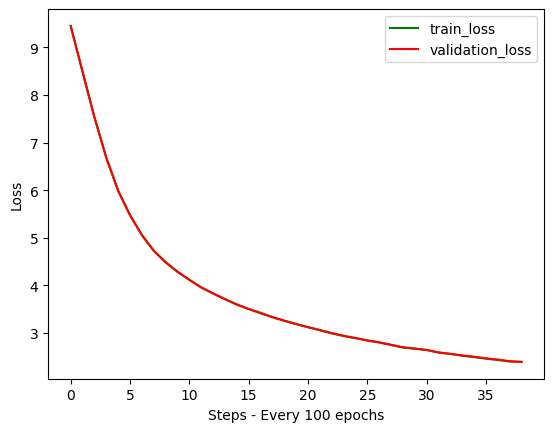

In [ ]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



## Step 10: Run SLM Inference and Generate Creative Stories ✨

Congratulations! You've successfully trained your Small Language Model. Now comes the most exciting part: putting it to work to generate new, creative text!

**Inference**, or text generation, is where our SLM takes a starting prompt and, based on everything it learned during training, predicts the most probable next tokens to continue the story. It's like giving our little linguistic wizard a beginning and watching it spin a tale.

In this step, we will:

1.  **Load the Best Model:** We'll load the weights of the model that achieved the best performance during validation, ensuring we use our finest storyteller.
2.  **Provide a Prompt:** You'll give the model a starting sentence or phrase.
3.  **Generate Text:** The model will use its learned patterns to predict subsequent tokens, building a coherent and creative continuation of your prompt.
4.  **Decode and Display:** The generated numerical tokens will be converted back into human-readable text using our `tiktoken` tokenizer.

Let's unleash our SLM's storytelling abilities! Feel free to experiment with different starting sentences and observe how our model generates unique stories based on the TinyStories dataset's style.

In [ ]:
#Load the model
model = GPT(config)  # re-create the model with same config
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states


<All keys matched successfully>

In [ ]:
sentence = "Once upon a time there was a pumpkin."
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

Once upon a time there was a pumpkin. It was very special. The pumpkin wanted to paint with its family. So one day, a family decided to make it you all the time. They worked hard to remove something.

 2 laser soldiers traveled and drove it grow into the sky. laughed like the whole."

The pumpkin stopped and smiled and felt happy for the tube. It sounded like it. Give it on big taller than it. They packed it and back up.

When it was done, the pumpkin had closed. It was relaxed and cozy. There were people that flying. Little Thursday workerAlright, the tower could during a bright, normal time. His friend said, "Trn into Lou, what can we do and find our flashlight?"

Her friend thought smellyly and said: "We can try to open it! It can be alright. We can find it". 

Joe was amazed. He wanted that if they could delay, they would come back back and mattered the sign


In [ ]:
sentence = "A little girl went to the woods"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

A little girl went to the woods and he was looking at the animals and he saw a little boy with a big smile on its face. He knew she would never bring medicine before.

One day, the girl called Jeff went for a walk. He saw something pretty in a nearby old structure. It was a kind of creature and he is leaning chillis and hiding. Lilly looked up at the octopus. Littleie felt very worried. She thought it looked colourful and funny. Then found a strange idea. She took the unknown and said, â€œufchieumbling, stone!â€

Ted the factory said, â€œI have a hero!â€; he was sure it will rise. 

Mary smiled and was not getting still there before. It was a powerful tw armor! And this made him even more he dream less very safe.It was a awesome day. John saw something sparkly and was a brilliant trick. It was a mighty think of something


In [ ]:
from google.colab import runtime
runtime.unassign()

## Conclusion: Your SLM Journey Continues! 🎉

Congratulations on completing this hands-on tutorial and building your very own Small Language Model from scratch! You've successfully navigated the exciting world of neural networks, tokenization, and text generation.

### What You've Achieved:

*   **Understanding SLMs:** You now grasp the fundamental concepts behind Small Language Models and their significance in the broader AI landscape.
*   **Data Mastery:** You've learned how to load, explore, tokenize, and efficiently prepare a dataset (TinyStories) for language model training.
*   **GPT Architecture:** You've deconstructed the core components of a Transformer-based GPT model, including embeddings, attention mechanisms, and feed-forward networks.
*   **Configuration & Parameters:** You've understood how to configure model hyperparameters and even calculated the parameter count of your SLM.
*   **Training Dynamics:** You've delved into loss functions, evaluation metrics, optimizers, learning rate schedulers, and the benefits of mixed-precision training.
*   **Model Training:** You've executed a full training loop, monitored its progress, and visualized the learning curves.
*   **Creative Generation:** Most excitingly, you've witnessed your SLM generate creative and coherent text based on your prompts!

### Where to Go Next?

This tutorial is just the beginning! Here are some ideas to continue your SLM exploration:

1.  **Experiment with Hyperparameters:** Try changing `n_layer`, `n_head`, `n_embd`, `block_size`, `learning_rate`, or `max_iters`. How do these changes affect training time, model size, and generation quality?
2.  **Explore Different Datasets:** While TinyStories is excellent for beginners, try applying your knowledge to other small text datasets. The Hugging Face `datasets` library offers many options!
3.  **Implement Advanced Features:** Research and try to implement features like Beam Search or Top-P (nucleus) sampling for text generation to get more diverse or controlled outputs.
4.  **Visualize Attention:** Can you add code to visualize the attention weights within a Transformer block? This can provide insights into what the model is "looking at."
5.  **Fine-tuning:** Learn about fine-tuning pre-trained models on specific tasks to achieve even better performance on specialized text generation.

Keep experimenting, keep learning, and most importantly, have fun with your newfound SLM superpowers! We hope this session for Indaba Nigeria 2026 has been a valuable and hands-on experience, and that your SLMs will soon be writing better jokes than I can!